In [1]:
#%% Import 
import os
import sys
import getopt
import h5py as h5
import numpy as np
import pandas as pd
import datetime as dt
import daz_lib_licsar as dl
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
framedir='/work/scratch-pw2/licsar/mnergiz/TR_interseismic_postseismic/inter/sbois_mw6/021D_05266_252525/'
frame=os.path.basename(framedir)
cumfile=os.path.join(framedir,'TS_GEOCml10/cum.h5')


In [3]:
# Load data
with h5.File(cumfile, 'r') as f:
    cum = f['cum'][()]
    imdates = f['imdates'][()].astype(str)
    tide = f['tide'][()]
    iono = f['iono'][()]

# # Reference all to first epoch
# cum = cum - cum[0]
# tide = tide - tide[0]
# iono = iono - iono[0]

# # Get daz correction (azimuth ionospheric delay)
# dazes = dl.get_daz_frame(frame)[['epoch', 'daz']]
# dazes['epoch'] = pd.to_datetime(dazes['epoch'])
# dazes['daz'] = dazes['daz'] * 14000  # Convert to mm (scale for azimuth geometry)

# # Interpolate daz to match imdates
# df_daz = pd.DataFrame({'epoch': pd.to_datetime(imdates)})
# df_daz = df_daz.merge(dazes, on='epoch', how='left').sort_values('epoch')
# df_daz['daz'] = df_daz['daz'].interpolate(method='nearest', limit_direction='both')
# daz = df_daz['daz'].to_numpy()
# daz = daz - daz[0]  # Align to first epoch

# # Apply all corrections
# cum_abs = cum + daz[:, None, None] - tide - iono

In [4]:
cuma = xr.load_dataset(cumfile)

In [5]:
cuma

<xarray.Dataset>
Dimensions:                (phony_dim_0: 469, phony_dim_1: 386,
                            phony_dim_2: 354, phony_dim_3: 353)
Dimensions without coordinates: phony_dim_0, phony_dim_1, phony_dim_2,
                                phony_dim_3
Data variables: (12/30)
    E.geo                  (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    N.geo                  (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    U.geo                  (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    bperp                  (phony_dim_2) float64 -84.0 -103.0 ... -35.0 81.0
    coh_avg                (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    corner_lat             float64 39.65
    ...                     ...
    cum_abs_notide         (phony_dim_2, phony_dim_0, phony_dim_1) float32 na...
    cum_abs_notide_noiono  (phony_dim_2, phony_dim_0, phony_dim_1) float32 na...
    vel                    (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    vel_abs                (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    vel_abs_notide         (phony_dim_0, phony_dim_1) float32 nan nan ... nan
    vel_abs_notide_noiono  (phony_dim_0, phony_dim_1) float32 nan nan ... nan

In [41]:
cuma.cum[1]

<xarray.DataArray 'cum' (phony_dim_0: 469, phony_dim_1: 386)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Dimensions without coordinates: phony_dim_0, phony_dim_1

In [32]:
tide_data[1]

<xarray.DataArray 'tide' (phony_dim_0: 468, phony_dim_1: 387)>
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], dtype=float32)
Dimensions without coordinates: phony_dim_0, phony_dim_1

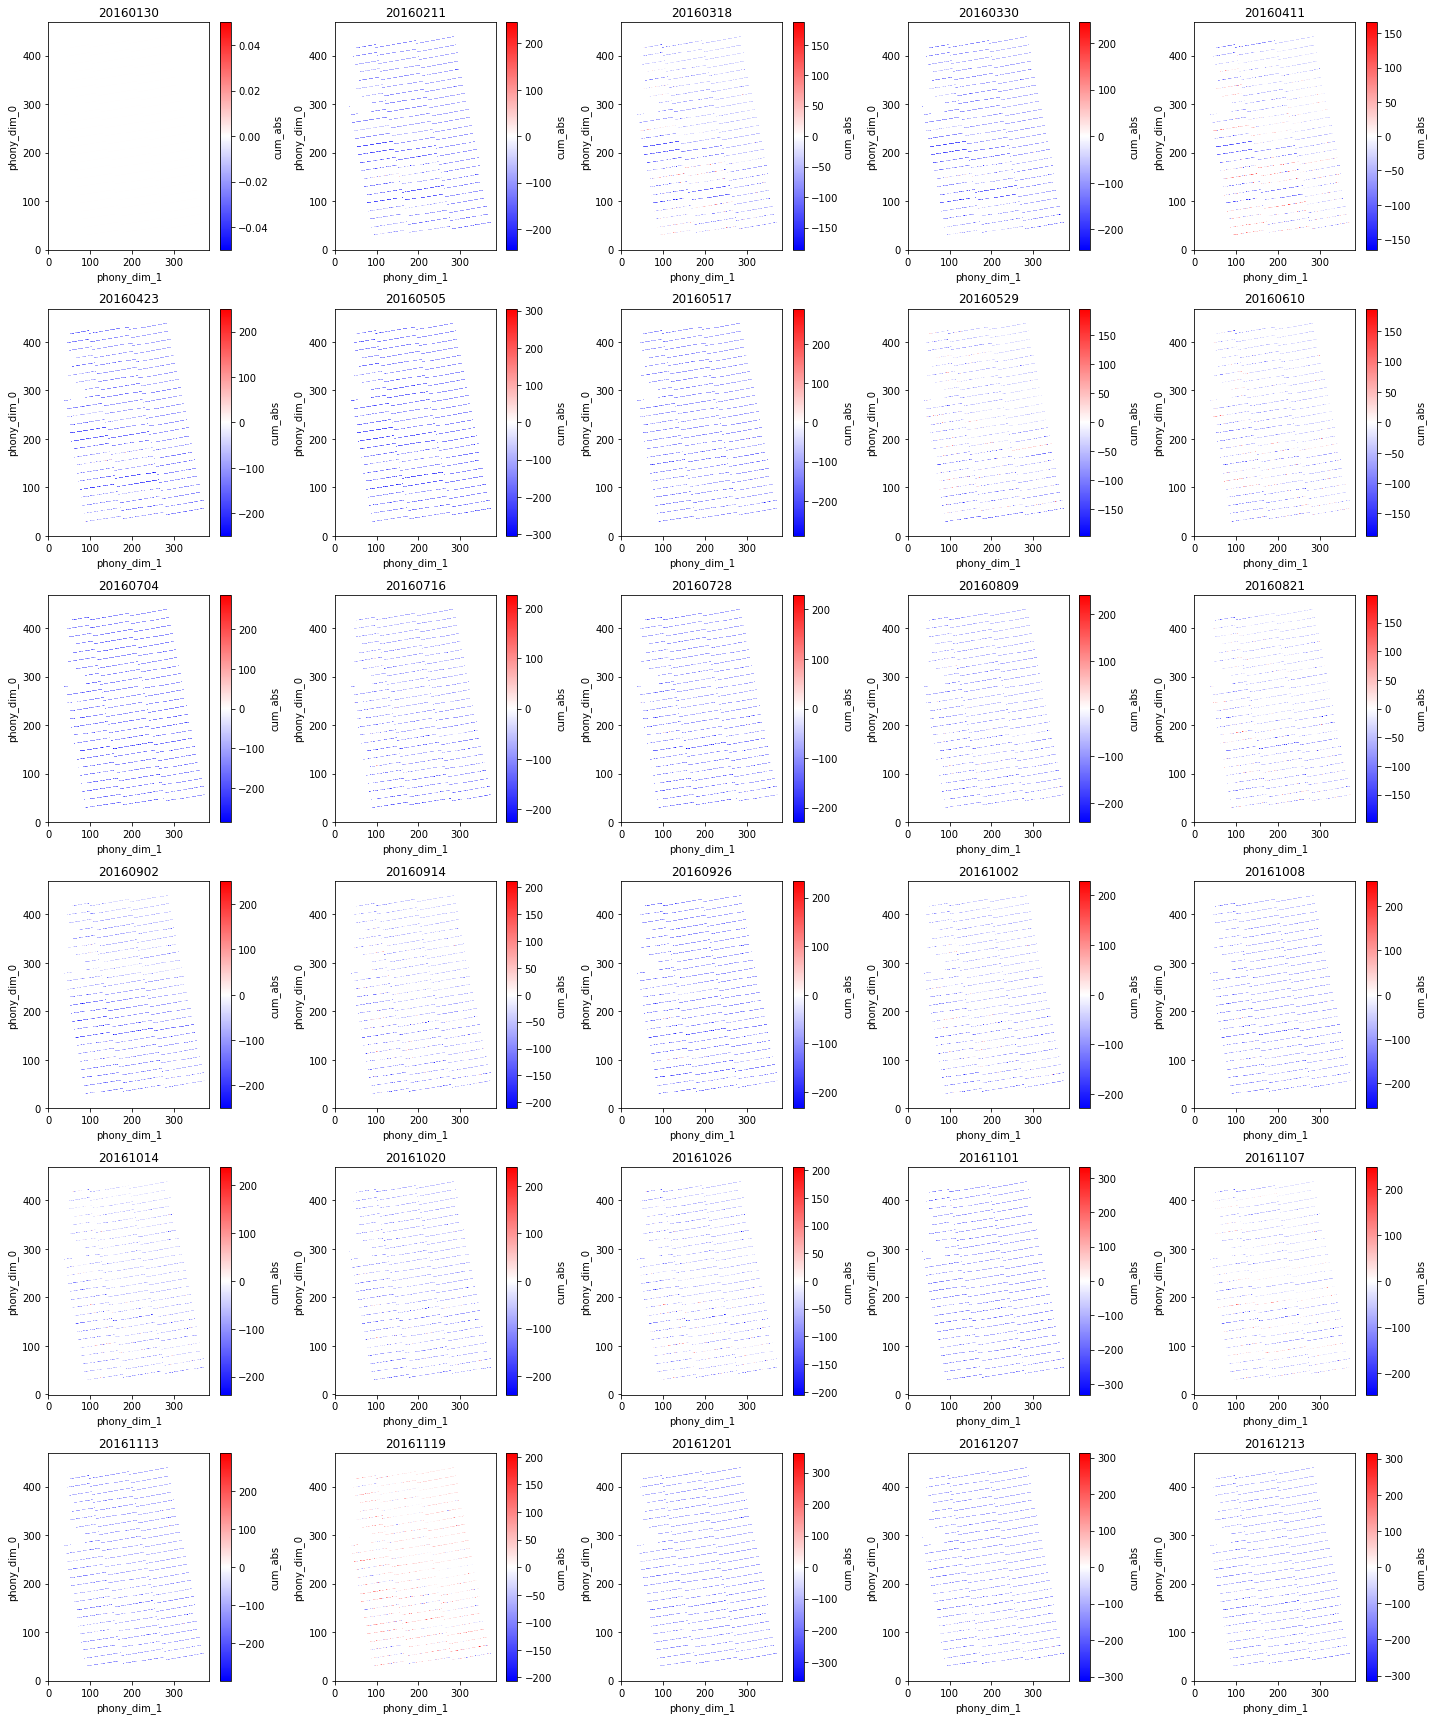

In [48]:
import matplotlib.pyplot as plt

# Select the first 30 slices of cuma.tide
tide_data = cuma['cum_abs']  # assuming cuma.tide exists
imdates = cuma['imdates']  # assuming cuma.imdates exists

# Set up the subplots
fig, axes = plt.subplots(6, 5, figsize=(20, 24))  # 6 rows, 5 columns
axes = axes.flatten()

# Plot each slice
for i in range(30):
    ax = axes[i]
    tide_data[i].plot(ax=ax, cmap='bwr')
    ax.set_title(str(imdates.values[i]))  # Set title using imdates

# Hide unused axes if any (shouldn't be necessary here)
for j in range(30, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

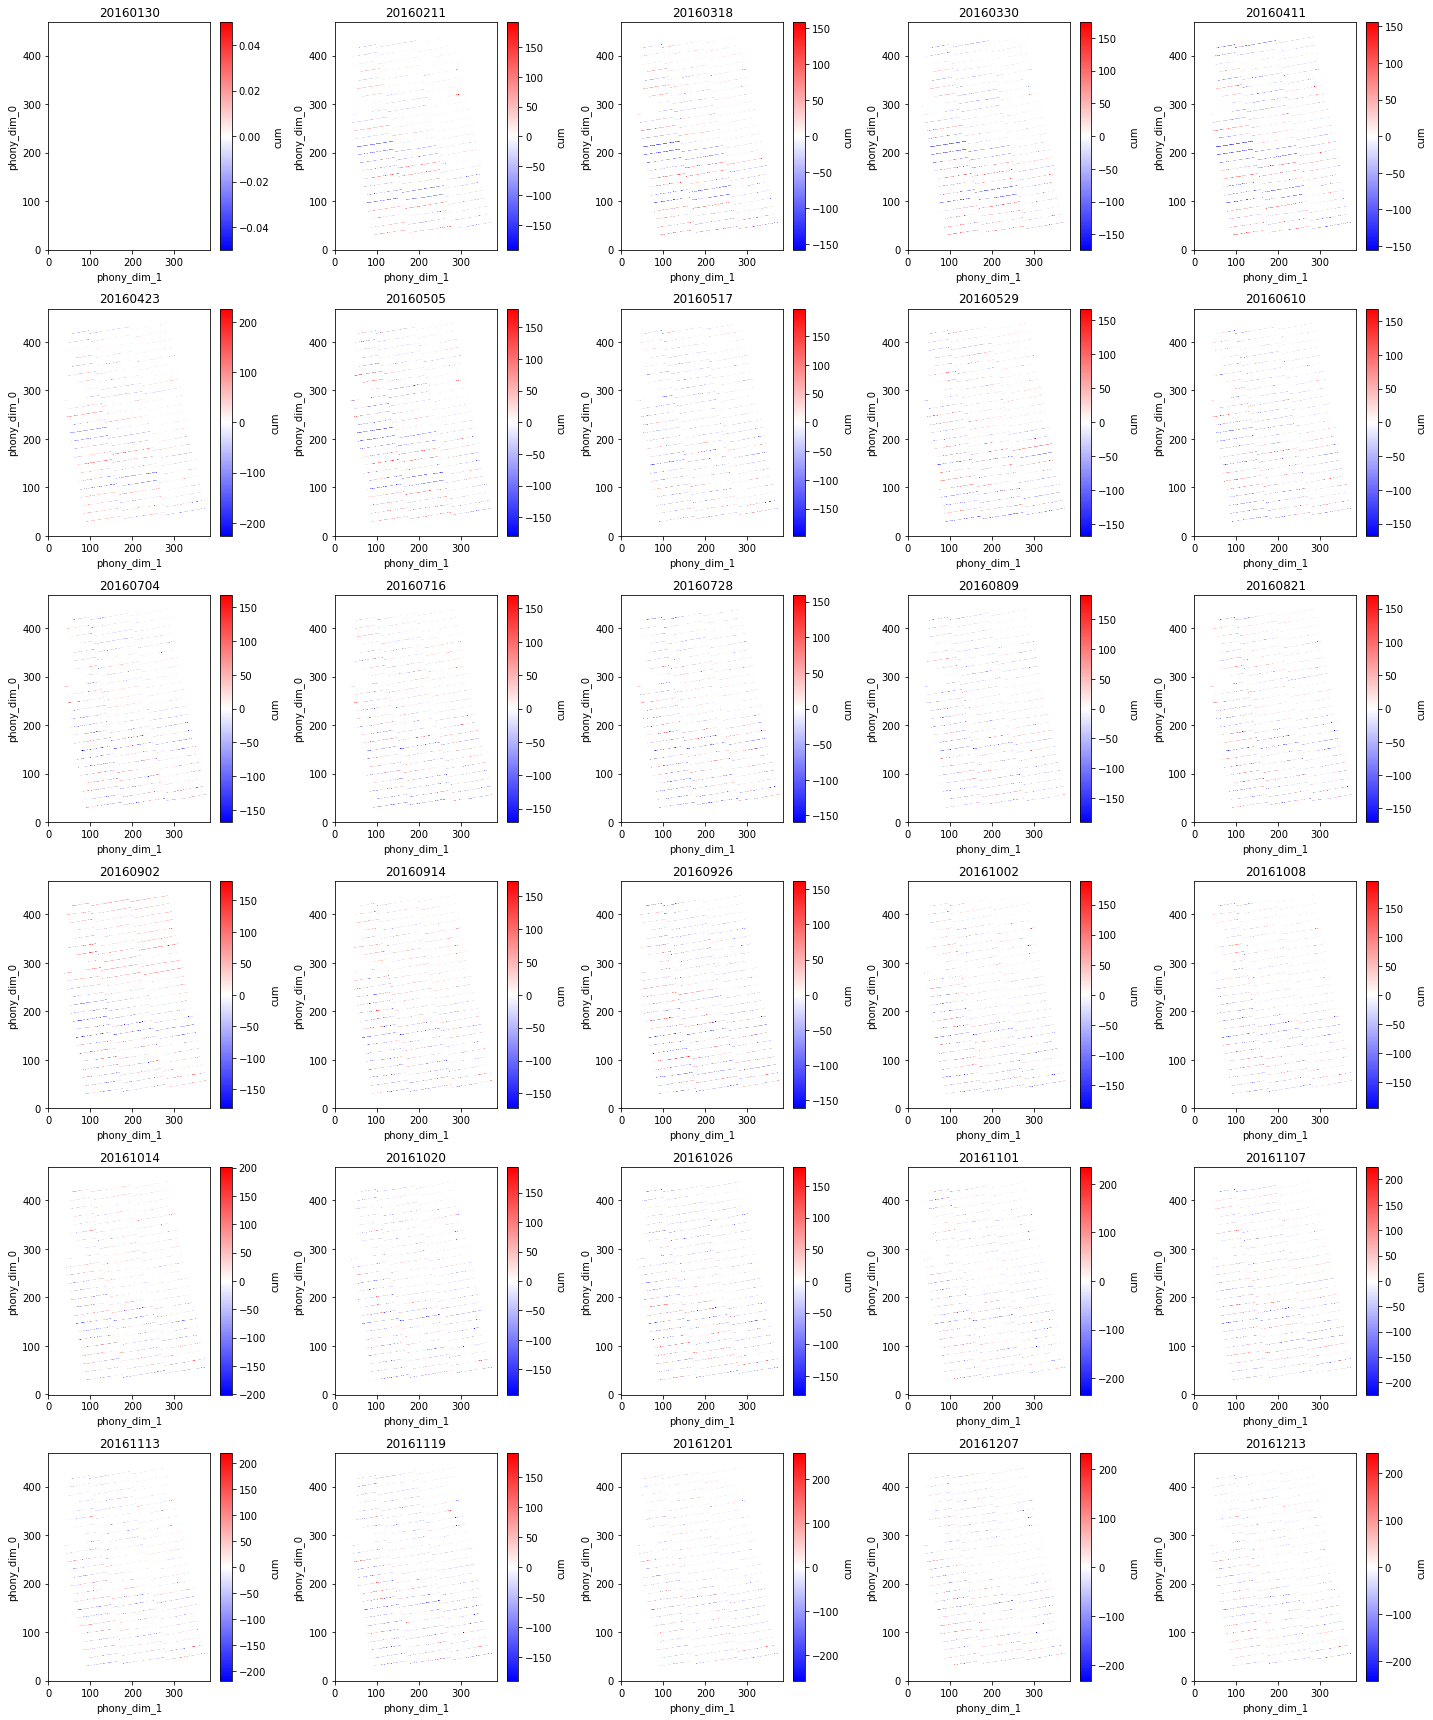

In [44]:
import matplotlib.pyplot as plt

# Select the first 30 slices of cuma.tide
tide_data = cuma['cum']  # assuming cuma.tide exists
imdates = cuma['imdates']  # assuming cuma.imdates exists

# Set up the subplots
fig, axes = plt.subplots(6, 5, figsize=(20, 24))  # 6 rows, 5 columns
axes = axes.flatten()

# Plot each slice
for i in range(30):
    ax = axes[i]
    tide_data[i].plot(ax=ax, cmap='bwr')
    ax.set_title(str(imdates.values[i]))  # Set title using imdates

# Hide unused axes if any (shouldn't be necessary here)
for j in range(30, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


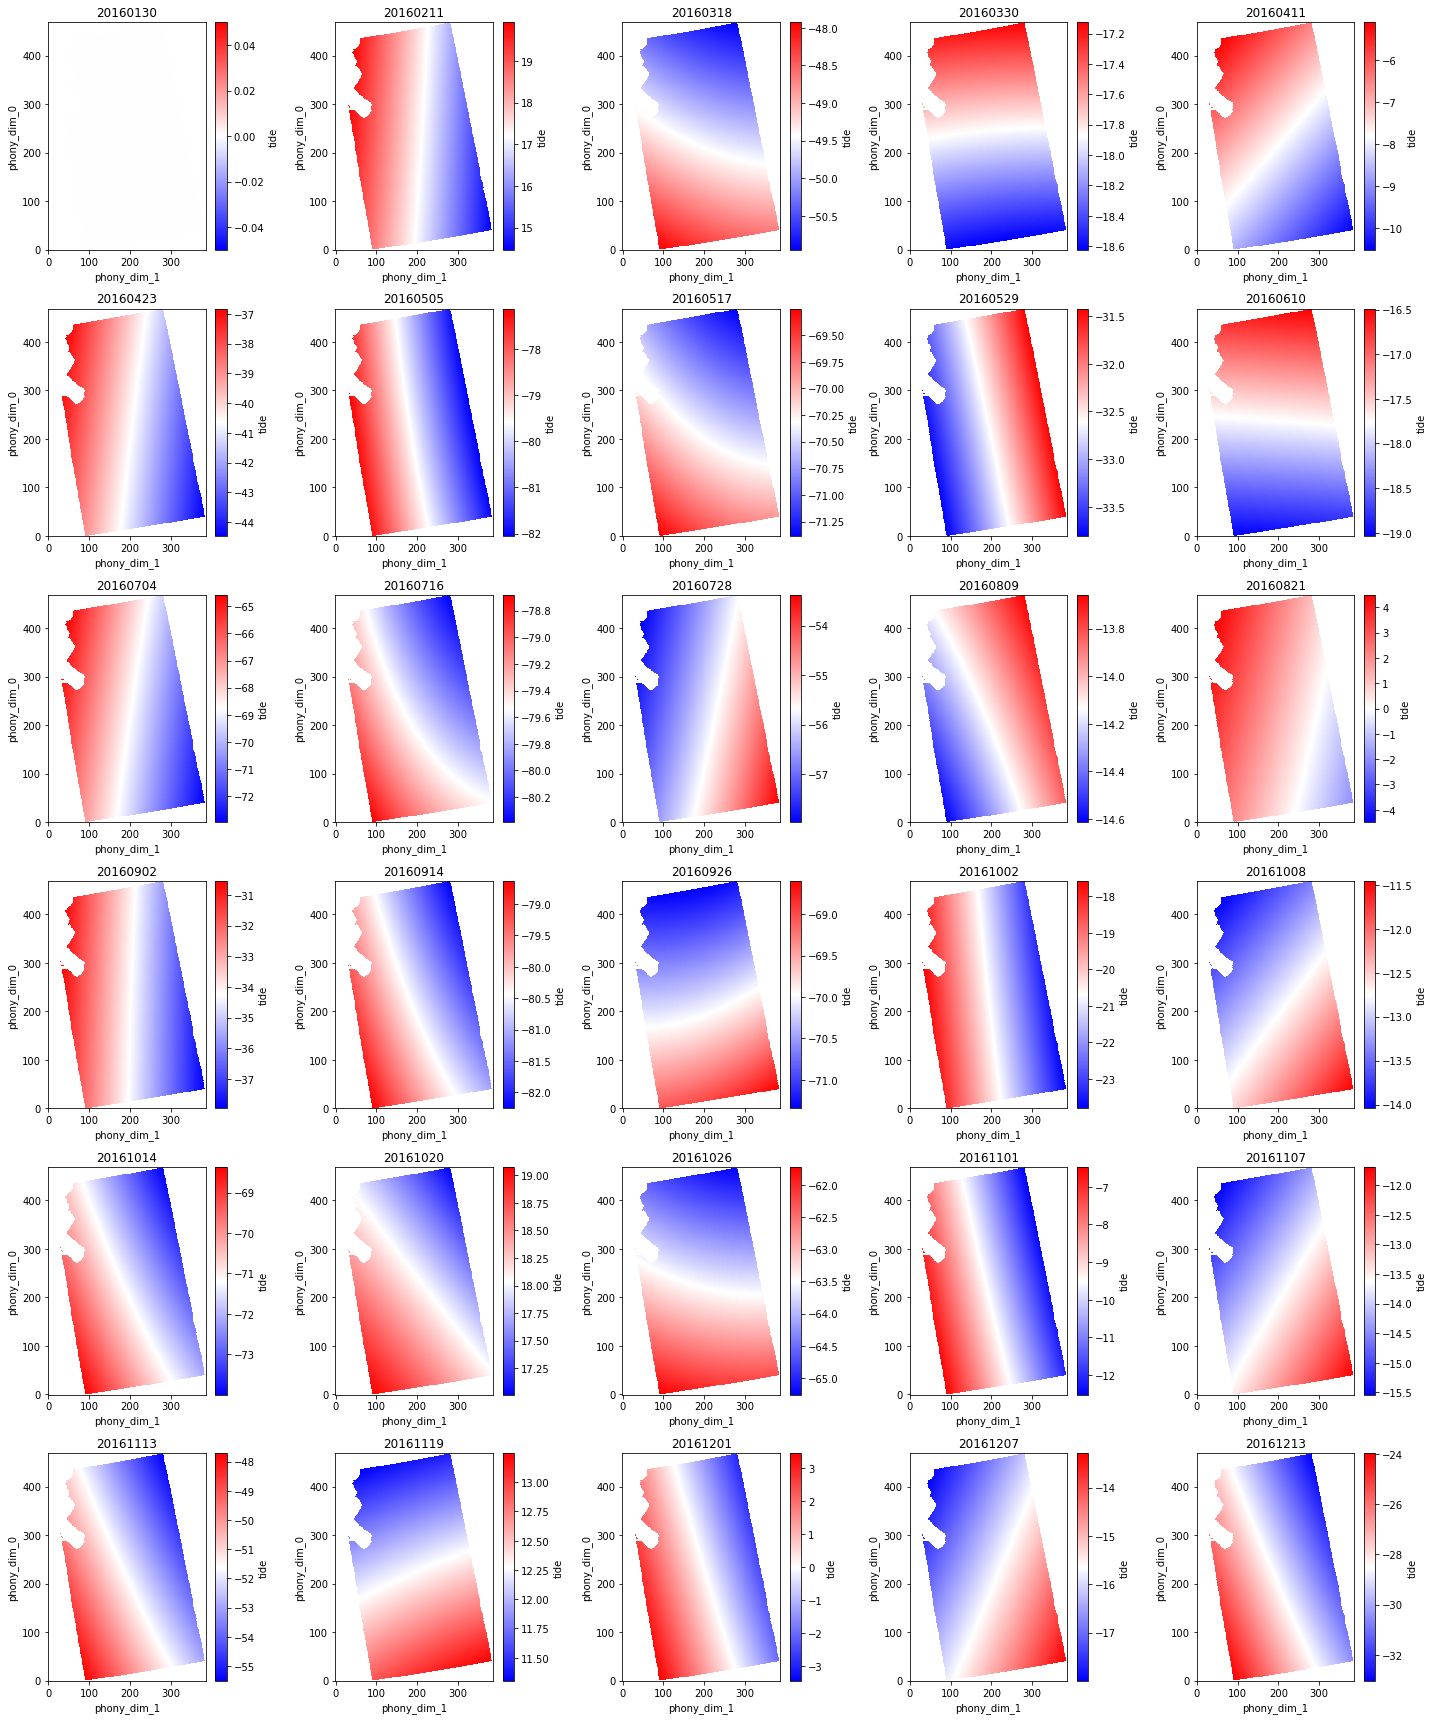

In [42]:
import matplotlib.pyplot as plt

# Select the first 30 slices of cuma.tide
tide_data = cuma['tide']  # assuming cuma.tide exists
imdates = cuma['imdates']  # assuming cuma.imdates exists

# Set up the subplots
fig, axes = plt.subplots(6, 5, figsize=(20, 24))  # 6 rows, 5 columns
axes = axes.flatten()

# Plot each slice
for i in range(30):
    ax = axes[i]
    tide_data[i].plot(ax=ax, cmap='bwr')
    ax.set_title(str(imdates.values[i]))  # Set title using imdates

# Hide unused axes if any (shouldn't be necessary here)
for j in range(30, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


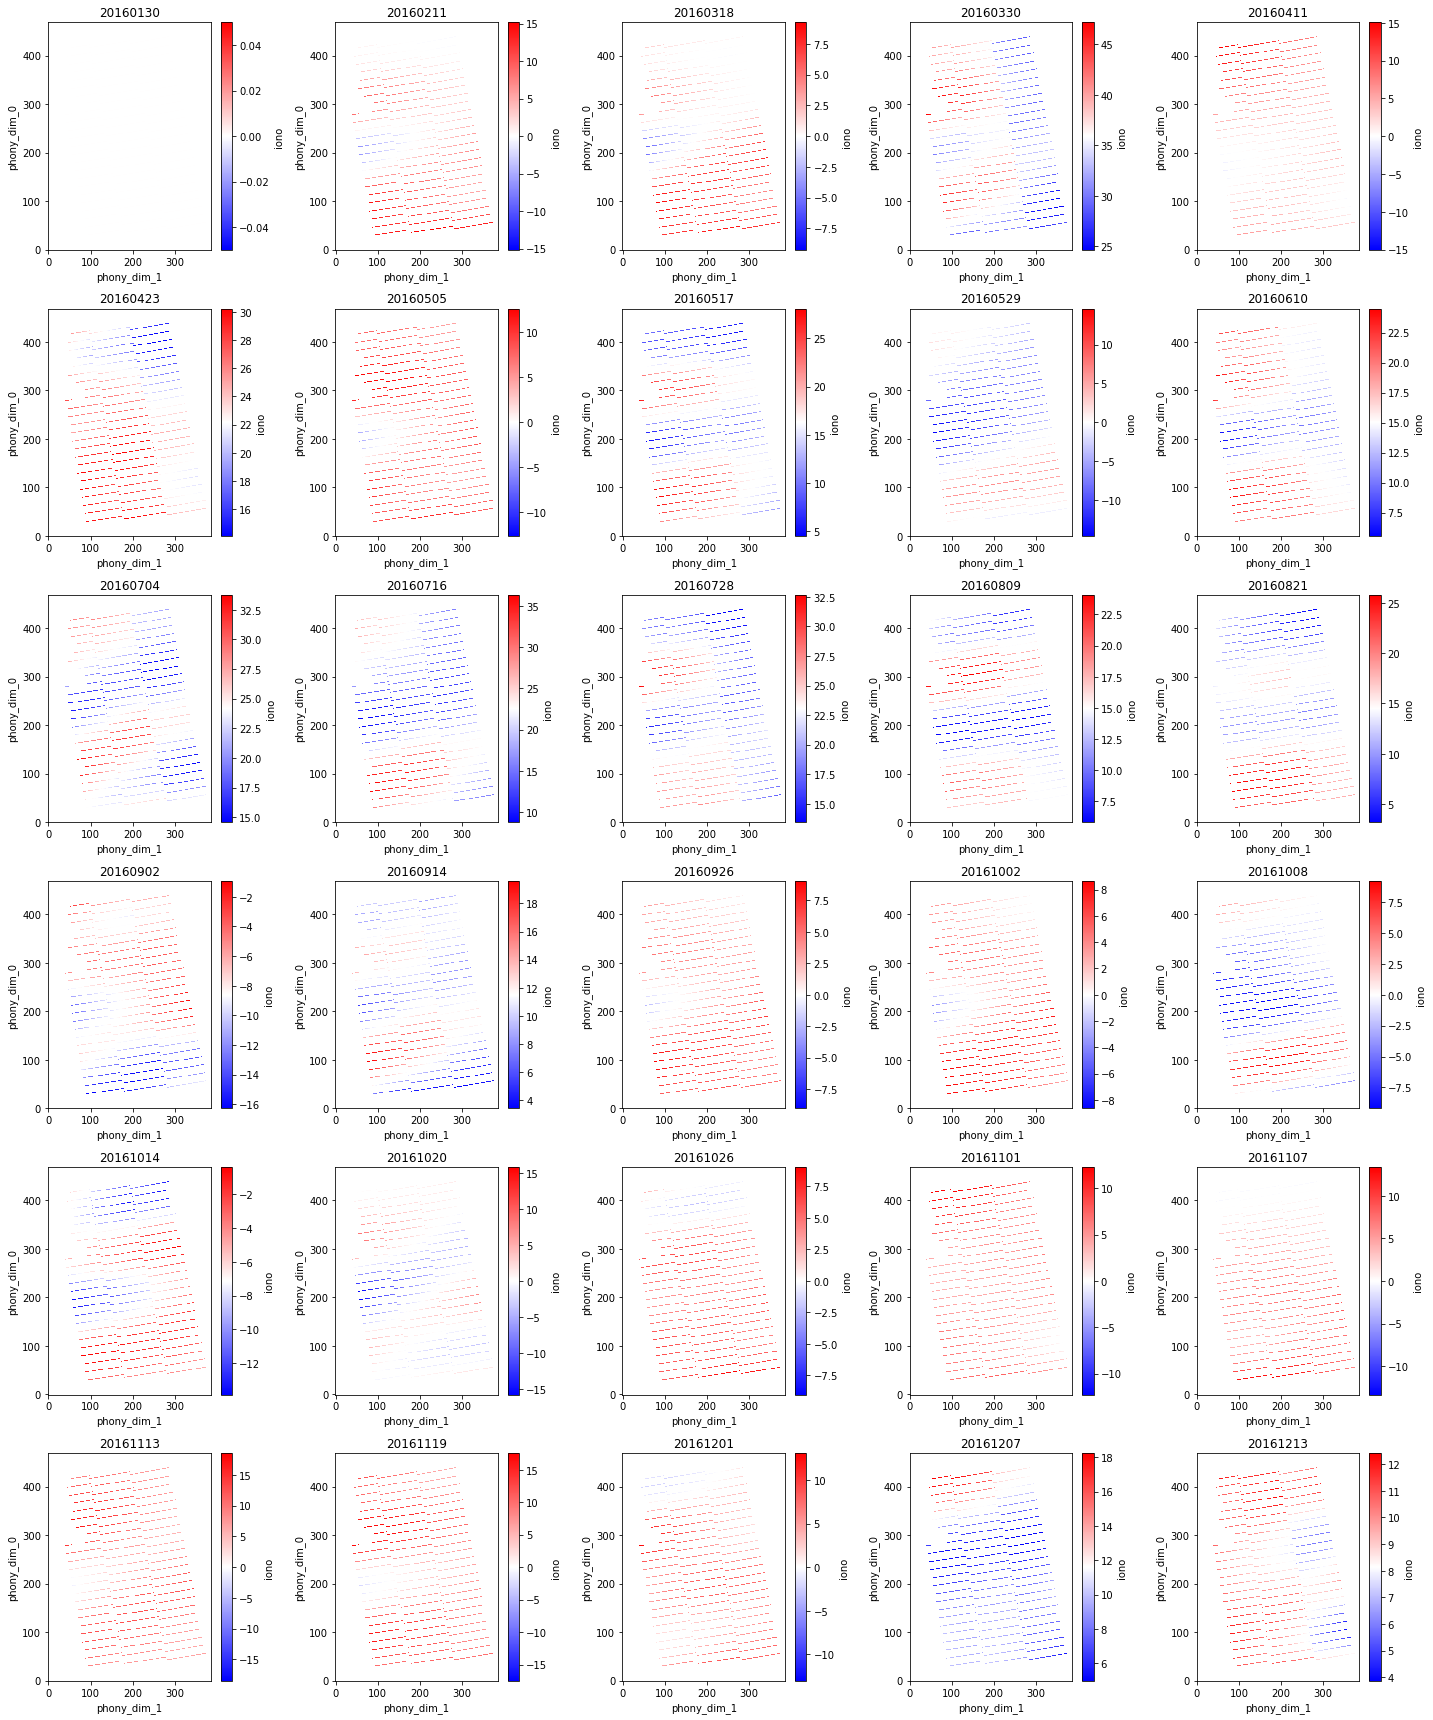

In [43]:
import matplotlib.pyplot as plt

# Select the first 30 slices of cuma.tide
tide_data = cuma['iono']  # assuming cuma.tide exists
imdates = cuma['imdates']  # assuming cuma.imdates exists

# Set up the subplots
fig, axes = plt.subplots(6, 5, figsize=(20, 24))  # 6 rows, 5 columns
axes = axes.flatten()

# Plot each slice
for i in range(30):
    ax = axes[i]
    tide_data[i].plot(ax=ax, cmap='bwr')
    ax.set_title(str(imdates.values[i]))  # Set title using imdates

# Hide unused axes if any (shouldn't be necessary here)
for j in range(30, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


Failed to process 116A_04978_131311: tuple index out of range


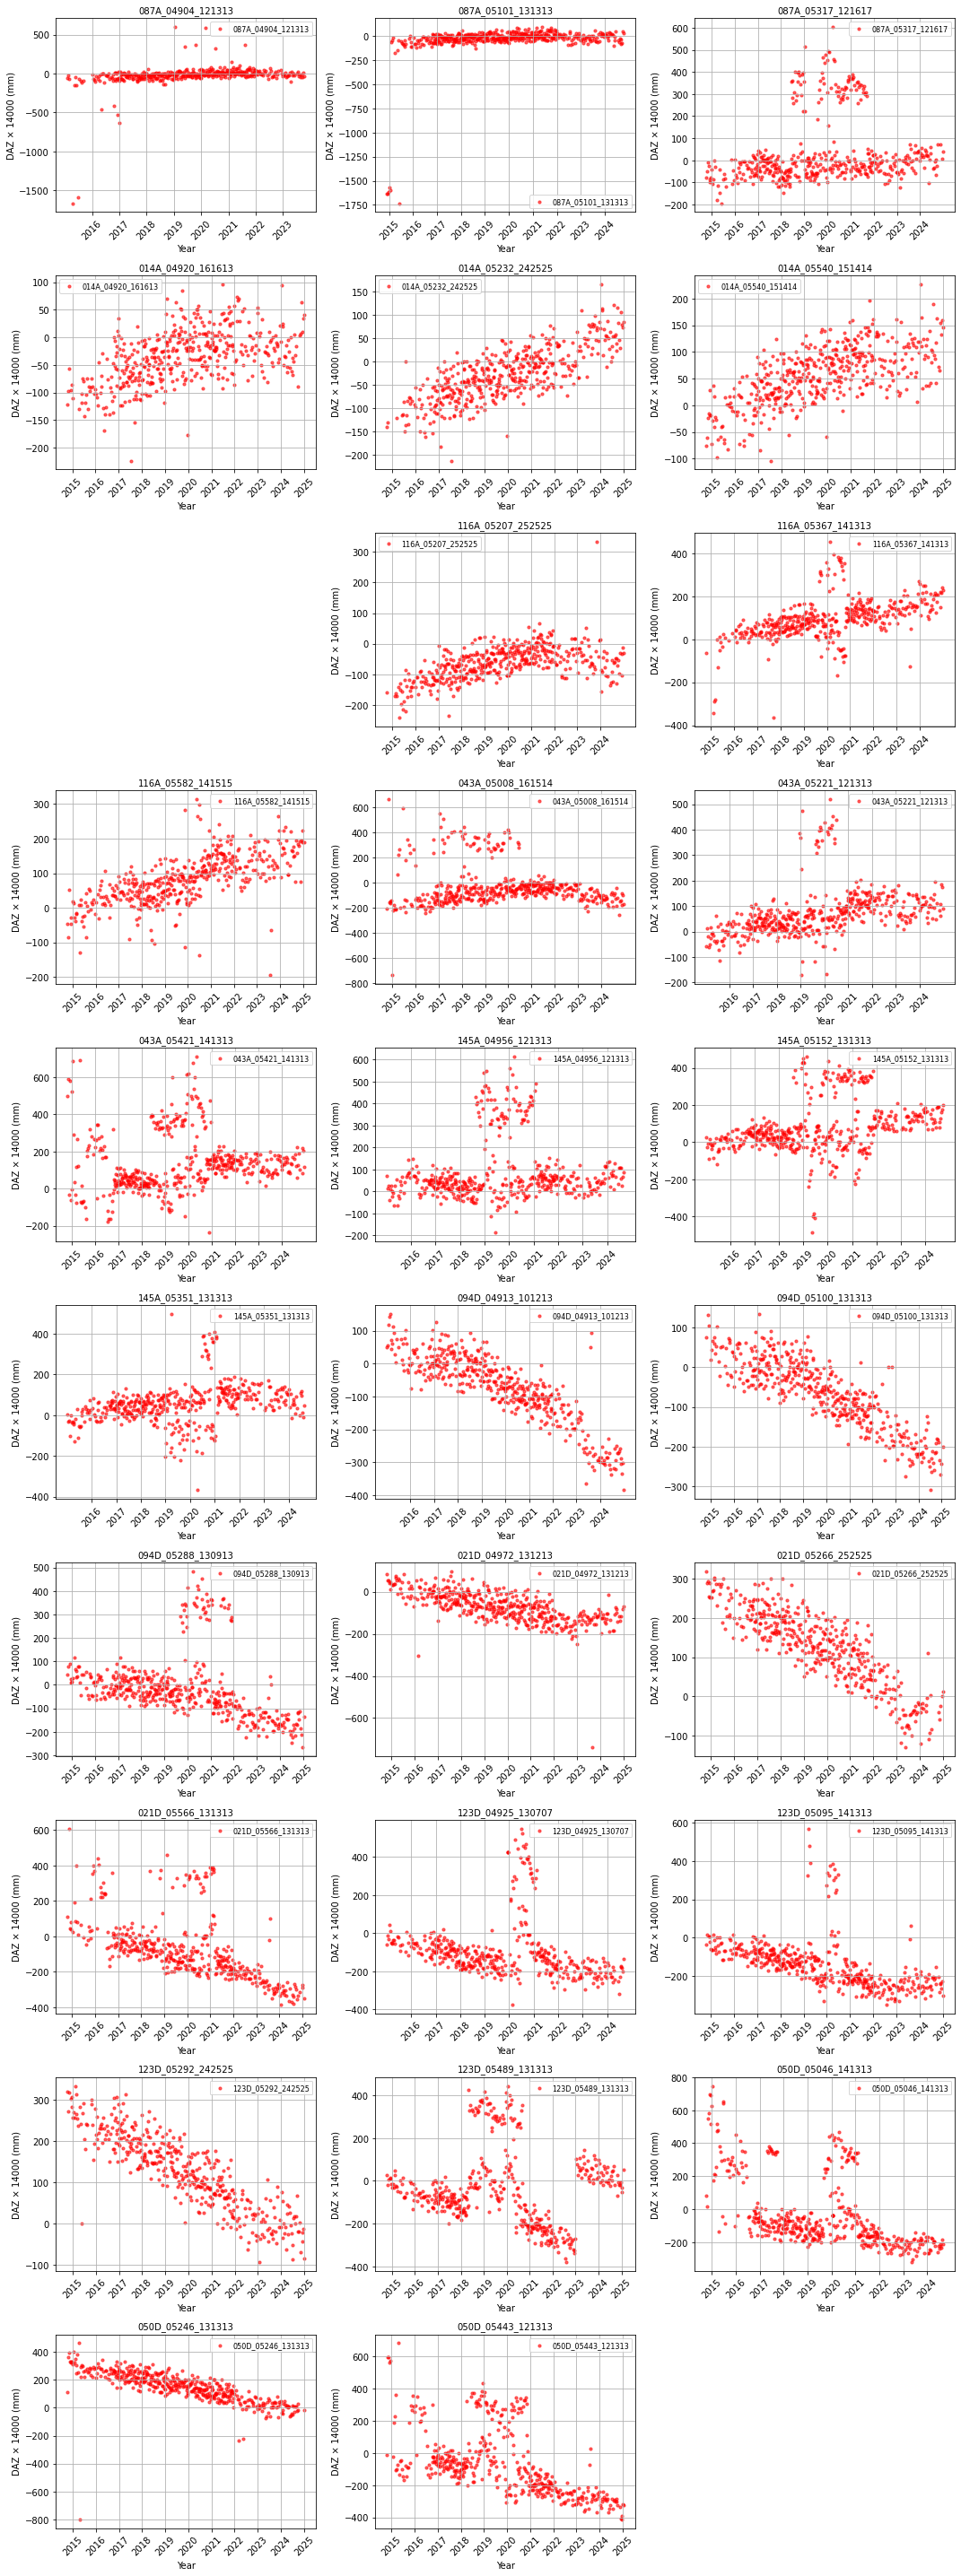

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Assuming you have a custom module 'dl' that provides your data
import daz_lib_licsar as dl

# Load frames_TR from file
homedir = '/home/users/mnergiz'
frames_file = os.path.join(homedir, 'frames_TR')

frames_TR = []
with open(frames_file, 'r') as f:
    for line in f:
        frames_TR.append(line.strip())

# Prepare subplots
n = len(frames_TR)
ncols = 3  # Number of plots per row
nrows = (n + ncols - 1) // ncols  # Auto calculate rows
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows), sharex=False)
axs = axs.flatten()

# Loop through each frame and plot
for i, frame in enumerate(frames_TR):
    try:
        # Load data
        df = dl.get_daz_frame(frame)[['epoch', 'daz']]
        df['epoch'] = pd.to_datetime(df['epoch'])
        df['daz'] = df['daz'] * 14000  # Convert to mm (scale for azimuth geometry)
        df['epoch'] = pd.to_datetime(df['epoch'], format='%Y%m%d')
        df = df.sort_values(by='epoch')

        # Plot
        axs[i].scatter(df['epoch'], df['daz'], color='red', alpha=0.6, s=10, label=frame)
        axs[i].set_title(frame, fontsize=10)
        axs[i].set_xlabel('Year')
        axs[i].set_ylabel('DAZ × 14000 (mm)')
        axs[i].legend(fontsize=8)
        axs[i].grid(True)
        xticks = pd.date_range(start=df['epoch'].min(), end=df['epoch'].max(), freq='YS')
        axs[i].set_xticks(xticks)
        axs[i].set_xticklabels(xticks.year, rotation=45)
    except Exception as e:
        print(f"Failed to process {frame}: {e}")
        axs[i].set_visible(False)

# Hide any unused subplots
for j in range(i + 1, len(axs)):
    axs[j].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
012A_04251_131313    20200823
012A_04449_131313    20200811
012A_04648_131313    20200811
012A_04857_141415    20200823
027A_04532_191920    20200905
027A_04887_262625    20200905
027A_05194_131313    20200812
056A_04414_191919    20220629
056A_04661_131313    20220629
056A_04947_282019    20201001
085A_04263_131313    20200828
085A_04461_131313    20200828
085A_04660_131313    20200828
085A_04859_131313    20200816
100A_04583_202020    20200817
100A_04841_131313    20200817
100A_05036_121313    20200606
100A_05236_141313    20160919
129A_04474_212121    20200912
129A_04740_131313    20200819
129A_04939_131313    20200819
129A_05138_131313    20200819
158A_04407_191919    20200914
158A_04656_131313    20200821
158A_04883_171715    20200821
173A_04555_131313    20200810
173A_04754_131313    20200810
173A_04952_131313    20200810
173A_05151_131313    20160912
005D_04404_131313    20200823
005D_04603_131313    20200811
005D_04801_131313    20200904
005D_05000_131313    20181126
034D_04318_131313    20190924
034D_04516_131313    20200801
034D_04714_131313    20200813
034D_04913_131313    20200912
034D_05112_131313    20200702
063D_04245_121111    20190704
063D_04429_121413    20190716
063D_04636_151314    20190716
063D_04886_161920    20190704
078D_04467_101010    20220830
078D_04640_131313    20200816
078D_04839_131313    20200828
078D_05037_131313    20160906
107D_04294_131313    20200812
107D_04493_131313    20200806
107D_04692_131313    20200818
107D_04890_131313    20200818
107D_05092_141313    20160920
136D_04254_121212    20200609
136D_04445_131313    20201013
136D_04643_131313    20201001
136D_04941_172131    20201001
165D_04270_131313    20190915
165D_04469_131313    20190915
165D_04666_131313    20190915
165D_04866_131313    20200804
078D_05237_131313    20160906
005D_05199_131313    20181126
107D_05290_121313    20221007
034D_05310_131313    20160915


In [2]:
get_daz_frame(frame, include_corrections = True)

NameError: name 'get_daz_frame' is not defined

In [3]:
df = dl.get_daz_frame(frame,  include_corrections = True)

NameError: name 'heading' is not defined

In [ ]:
df